# End-to-End Machine Learning Project: Airbnb Price Prediction

This project develops an end-to-end machine learning pipeline for predicting Airbnb listing prices using the New York City Airbnb Open Data dataset.

The workflow includes:
- Data loading and exploration
- Data quality assessment
- Price distribution and outlier analysis
- Feature selection
- Train-test splitting
- Data preprocessing
- Regression model development
- Model comparison
- Overfitting analysis
- Hyperparameter tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import joblib

## 1. Load the Dataset

The Airbnb dataset is loaded into a Pandas DataFrame for further analysis and model development.

The dataset used in this project is the **New York City Airbnb Open Data (`AB_NYC_2019.csv`)**.

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 2. Dataset Dimensions

The shape of the dataset is examined to determine the number of observations and features available for analysis.

In [3]:
print("Shape:",df.shape)

Shape: (48895, 16)


## 3. Dataset Information

The `info()` method is used to inspect:

- Number of observations
- Number of columns
- Data types of variables
- Non-null values
- Potential missing values

This helps identify the structure and data quality of the dataset before preprocessing.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 4. Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to understand their central tendency, dispersion, and range.

Important statistics include:
- Count
- Mean
- Standard deviation
- Minimum
- 25th percentile
- Median
- 75th percentile
- Maximum

This provides an initial understanding of the numerical characteristics of the Airbnb listings.

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## 5. Missing Value Analysis

The number of missing values in each feature is examined.

Identifying missing values is an important preprocessing step because machine learning models generally require appropriate handling of incomplete observations.

The missing-value information will be considered when designing the preprocessing pipeline.

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## 6. Duplicate Row Analysis

The dataset is checked for duplicate rows.

Duplicate observations can introduce unnecessary repetition in the dataset and may affect model training and evaluation. Therefore, the number of duplicate records is identified before proceeding with further analysis.

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Exploratory Data Analysis

## 7. Price Variable Analysis

Since `price` is the target variable, its statistical properties are examined separately.

Understanding the distribution and range of Airbnb prices is important before developing the regression models.

In [8]:
df["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

## 8. Distribution of Airbnb Prices

The distribution of Airbnb prices is visualized using a histogram with a kernel density estimate.

This visualization helps identify:

- The central region of the price distribution
- Skewness
- The presence of extreme prices
- The overall variability of Airbnb prices

The distribution is expected to be highly right-skewed because Airbnb listings can have substantially different nightly prices.

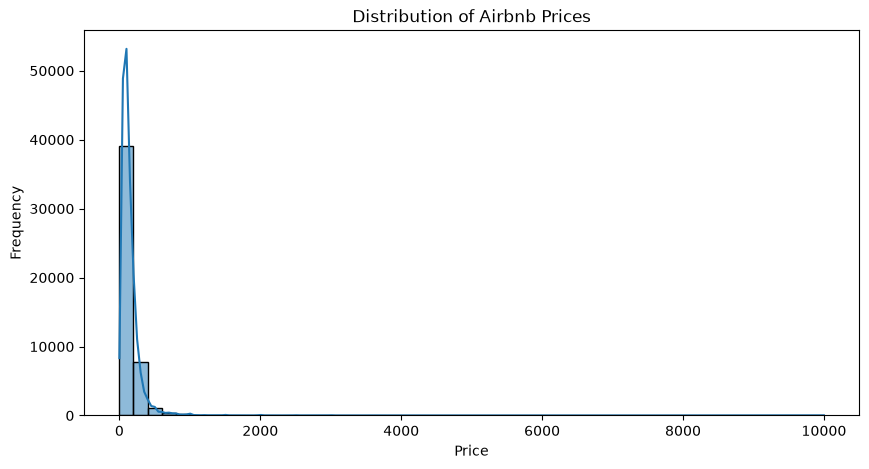

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


## 9. Price Quantile Analysis

Different price quantiles are calculated to understand how Airbnb prices are distributed across the dataset.

The selected quantiles provide information about:
- Very low-priced listings
- Lower and upper quartiles
- Median price
- High-priced listings
- Extreme price values

This analysis is useful for identifying potential outliers in the target variable.

In [10]:
df["price"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01     30.0
0.05     40.0
0.25     69.0
0.50    106.0
0.75    175.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

## 10. Investigation of High-Priced Listings

The listings with the highest prices are examined along with their neighbourhood, room type, and price.

This step helps investigate extreme observations and understand whether unusually high prices represent legitimate Airbnb listings or potential data-quality issues.

In [11]:
df.sort_values("price", ascending=False)[
    ["name", "neighbourhood", "room_type", "price"]
].head(20)

,name,neighbourhood,room_type,price
29238,1-BR Lincoln Center,Upper West Side,Entire home/apt,10000
9151,Furnished room in Astoria apartment,Astoria,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Greenpoint,Entire home/apt,10000
6530,Spanish Harlem Apt,East Harlem,Entire home/apt,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Lower East Side,Entire home/apt,9999
12342,"Quiet, Clean, Lit @ LES & Chinatown",Lower East Side,Private room,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Tribeca,Entire home/apt,8500
4377,Film Location,Clinton Hill,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Upper East Side,Entire home/apt,7703
42523,70' Luxury MotorYacht on the Hudson,Battery Park City,Entire home/apt,7500


## 11. Data Cleaning

Listings with a price less than or equal to zero are removed because a valid Airbnb nightly price must be positive.

This ensures that the target variable contains meaningful values for regression modeling.

In [12]:
df = df[df["price"]>0].copy()

# 12. Feature Selection

Relevant features are selected based on their potential relationship with Airbnb listing prices.

The selected features describe:

- Geographic location
- Neighbourhood
- Room type
- Minimum number of nights
- Number of reviews
- Review frequency
- Host listing count
- Availability

The target variable for the regression task is `price`.

In [13]:
features=[
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]
target = "price"

## 13. Define Features and Target Variable

The dataset is divided into:

- **Features (`X`)**: Input variables used by the machine learning models.
- **Target (`y`)**: Airbnb nightly price that the models aim to predict.

This separation prepares the dataset for supervised regression modeling.

In [14]:
X = df[features]
y = df[target]

# 14. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

- **80%** of the observations are used for model training.
- **20%** are reserved for final testing.

A fixed `random_state=42` is used to ensure reproducibility.

The test set remains unseen during model training and is used to evaluate how well the trained models generalize to unseen data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

## 15. Verify Training and Testing Data

The dimensions of the training and testing datasets are displayed to verify that the data has been split correctly.

In [16]:
print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (39107, 10)
Test data: (9777, 10)


# 16. Identify Numerical and Categorical Features

The selected predictors are divided into two groups:

### Categorical Features
- `neighbourhood_group`
- `neighbourhood`
- `room_type`

### Numerical Features
- `latitude`
- `longitude`
- `minimum_nights`
- `number_of_reviews`
- `reviews_per_month`
- `calculated_host_listings_count`
- `availability_365`

Different preprocessing techniques are required for numerical and categorical variables.

In [17]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

## 17. Numerical Feature Preprocessing

A preprocessing pipeline is created for numerical variables.

Two preprocessing operations are performed:

1. **Median Imputation**  
   Missing numerical values are replaced with the median of the corresponding feature.

2. **Standardization**  
   Numerical features are standardized using `StandardScaler`.

Standardization transforms numerical variables to a comparable scale, which is useful when features have different ranges.

In [18]:
numerical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
        ]
)

## 18. Categorical Feature Preprocessing

A separate preprocessing pipeline is created for categorical variables.

The following operations are performed:

1. Missing categorical values are replaced using the most frequent category.
2. Categorical variables are converted into numerical representations using One-Hot Encoding.

`handle_unknown="ignore"` ensures that unseen categories encountered during prediction do not cause an error.

In [19]:
categorical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

## 19. Combined Preprocessing Pipeline

The numerical and categorical preprocessing pipelines are combined using `ColumnTransformer`.

This allows different transformations to be applied to different feature types while maintaining a single preprocessing workflow.

The resulting preprocessor can then be integrated directly with the machine learning models using a Scikit-learn `Pipeline`.

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numerical_transformer, numerical_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

# 20. Model Development

## 20.1 Linear Regression

Linear Regression is used as a baseline regression model.

It assumes that the target variable can be represented approximately as a linear combination of the input features.

The preprocessing pipeline is combined with the Linear Regression model so that preprocessing and prediction are performed as a single workflow.

In [21]:
linear_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

## 20.2 Random Forest Regression

Random Forest Regression is implemented as a nonlinear ensemble model.

It combines multiple decision trees and averages their predictions to obtain the final regression output.

Random Forest can capture nonlinear relationships and interactions between features that may not be captured effectively by Linear Regression.

In [22]:
random_forest_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]
)

## 20.3 Gradient Boosting Regression

Gradient Boosting Regression is used as another nonlinear ensemble learning approach.

The model builds a sequence of decision trees where each successive tree attempts to improve the errors made by the previous trees.

Gradient Boosting is suitable for regression problems involving complex nonlinear relationships between the predictors and the target variable.

In [23]:
gradient_boosting_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
        ]
)

## 20.4 Define Candidate Models

The three regression pipelines are stored in a dictionary so that they can be trained and evaluated using the same procedure.

The candidate models are:

1. Linear Regression
2. Random Forest Regression
3. Gradient Boosting Regression

Using a common evaluation loop ensures a consistent comparison between the models.

In [24]:
models = {
    "Linear Regression": linear_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

# 21. Model Training and Evaluation

Each candidate regression model is trained using the training dataset and evaluated on the unseen test dataset.

The following regression metrics are calculated:

### Mean Absolute Error (MAE)
Measures the average absolute difference between actual and predicted prices.

### Root Mean Squared Error (RMSE)
Measures the square root of the average squared prediction error and gives greater importance to large errors.

### R² Score
Measures the proportion of variance in Airbnb prices explained by the model.

These metrics provide complementary information about model performance.

In [25]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
})

## 22. Model Performance Comparison

The evaluation results from all candidate models are converted into a DataFrame and sorted according to RMSE.

This allows the regression models to be compared using a common evaluation framework.

A lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that the model explains a greater proportion of the variation in the target variable.

In [26]:
results_df = pd.DataFrame(results)
results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Gradient Boosting,66.172267,181.976622,0.172856
0,Linear Regression,70.740417,186.096761,0.134977
1,Random Forest,66.944772,196.412535,0.036419


# 23. Initial Best Model Selection

Based on the initial model evaluation, Gradient Boosting is selected as the model to be investigated further through hyperparameter tuning.

The purpose of hyperparameter tuning is to search for a better combination of model parameters that can improve predictive performance and generalization.

In [27]:
best_model = gradient_boosting_pipeline

# 24. Overfitting and Underfitting Analysis

The selected Gradient Boosting model is evaluated on both the training and testing datasets.

The training and testing R² scores are compared to assess model generalization.

### Interpretation

- A very large difference between training and testing performance may indicate **overfitting**.
- Low performance on both training and testing data may indicate **underfitting**.
- Similar training and testing performance generally indicates better generalization.

This diagnostic helps determine whether further model optimization is required.

In [29]:
train_prediction = best_model.predict(X_train)
test_prediction = best_model.predict(X_test)

train_r2 = r2_score(y_train, train_prediction)
test_r2 = r2_score(y_test, test_prediction)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 0.29916473493705575
Test R²: 0.17285610409114238


# 25. Hyperparameter Tuning

## 25.1 Define the Hyperparameter Grid

Hyperparameter tuning is performed for the Gradient Boosting Regressor.

The following hyperparameters are investigated:

### `n_estimators`
Controls the number of boosting stages or decision trees.

### `learning_rate`
Controls the contribution of each individual tree to the final model.

### `max_depth`
Controls the maximum depth of the individual decision trees.

A grid of candidate values is created so that different combinations can be systematically evaluated.

## 25.2 Grid Search with Cross-Validation

`GridSearchCV` is used to systematically evaluate all combinations of the selected Gradient Boosting hyperparameters.

A **3-fold cross-validation** strategy is used.

The model is evaluated using:

```text
Negative Root Mean Squared Error

In [31]:
from sklearn.model_selection import KFold, GridSearchCV

cv_strategy = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

parameter_grid_gradient_boosting = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=parameter_grid_gradient_boosting,
    cv=cv_strategy,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)


## 25.3 Execute Hyperparameter Search

The GridSearchCV object is fitted using the training dataset.

During this process, different combinations of Gradient Boosting hyperparameters are evaluated using 3-fold cross-validation.

The best-performing hyperparameter combination will be selected automatically based on the specified evaluation metric.

In [32]:
gradient_boosting_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation

## 25.4 Best Hyperparameters

After performing GridSearchCV, the best combination of hyperparameters is selected based on the lowest Root Mean Squared Error (RMSE) obtained through 5-fold cross-validation.

In [33]:
print("Best Hyperparameters:")
print(gradient_boosting_grid_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-gradient_boosting_grid_search.best_score_)

Best Hyperparameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}

Best Cross-Validation RMSE:
232.56358344389366


## 26. Final Tuned Gradient Boosting Model

The best estimator obtained from GridSearchCV is selected as the final Gradient Boosting model.

In [34]:
best_model = gradient_boosting_grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('categorical',
                                               

In [35]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['neighbourhood_group','neighbourhood','latitude',...,'reviews_per_month', 'calculated_host_listings_count','availability_365']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passe

## 27. Predictions Using the Tuned Model

The tuned model is used to generate predictions on both the training and testing datasets. Training performance is compared with testing performance to identify possible overfitting or underfitting.

In [36]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

## 28. Final Model Evaluation

The final model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

MAE measures the average absolute prediction error.

RMSE gives greater penalty to large prediction errors.

R² measures the proportion of variance in Airbnb prices explained by the model.

In [37]:
# Training metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print("\nTraining Performance:")
print(f"MAE  : {train_mae:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"R²   : {train_r2:.4f}")

print("\nTesting Performance:")
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")

FINAL MODEL PERFORMANCE

Training Performance:
MAE  : 68.70
RMSE : 229.78
R²   : 0.1496

Testing Performance:
MAE  : 67.64
RMSE : 184.27
R²   : 0.1519


## 29. Final Performance Summary

The following table summarizes the training and testing performance of the tuned Gradient Boosting model.

In [38]:
final_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2 Score": [train_r2, test_r2]
})

final_results

,Dataset,MAE,RMSE,R2 Score
0,Training,68.704667,229.784570,0.149619
1,Testing,67.639816,184.272383,0.151854


## 30. Overfitting and Underfitting Analysis

The difference between training and testing R² is examined to determine whether the model is overfitting or underfitting.

- A very high training R² and substantially lower testing R² indicates overfitting.
- Low training and testing R² indicates underfitting.
- Similar training and testing R² values indicate better generalization.

In [39]:
r2_gap = train_r2 - test_r2

print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")
print(f"R² Gap      : {r2_gap:.4f}")

if r2_gap > 0.10:
    print("\nModel may be overfitting.")
elif train_r2 < 0.60 and test_r2 < 0.60:
    print("\nModel may be underfitting.")
else:
    print("\nModel shows reasonably good generalization.")

Training R² : 0.1496
Testing R²  : 0.1519
R² Gap      : -0.0022

Model may be underfitting.


## 31. Actual vs Predicted Prices

The Actual vs Predicted plot compares the real Airbnb prices with the prices predicted by the tuned model.

A perfect regression model would place all observations along the diagonal line.

Greater deviation from the diagonal indicates larger prediction errors.

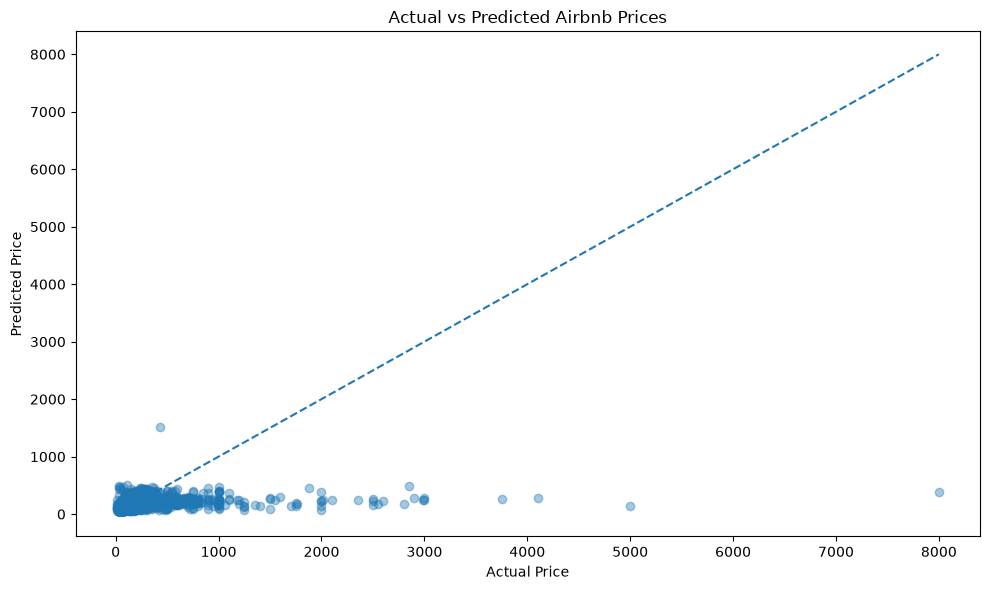

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")

plt.tight_layout()
plt.show()

## 32. Residual Analysis

Residuals are calculated as the difference between actual and predicted prices.

Residual:

\[
Residual = Actual - Predicted
\]

A good regression model should have residuals distributed around zero without a strong systematic pattern.

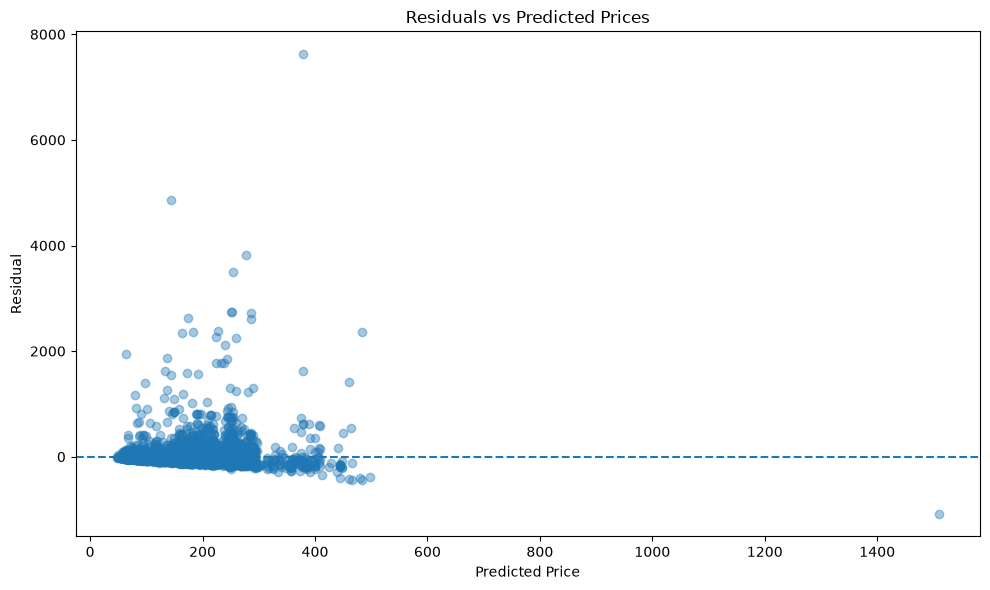

In [41]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Prices")

plt.tight_layout()
plt.show()

## 33. Distribution of Residuals

The residual distribution is examined to understand whether prediction errors are centered around zero and whether extreme errors are present.

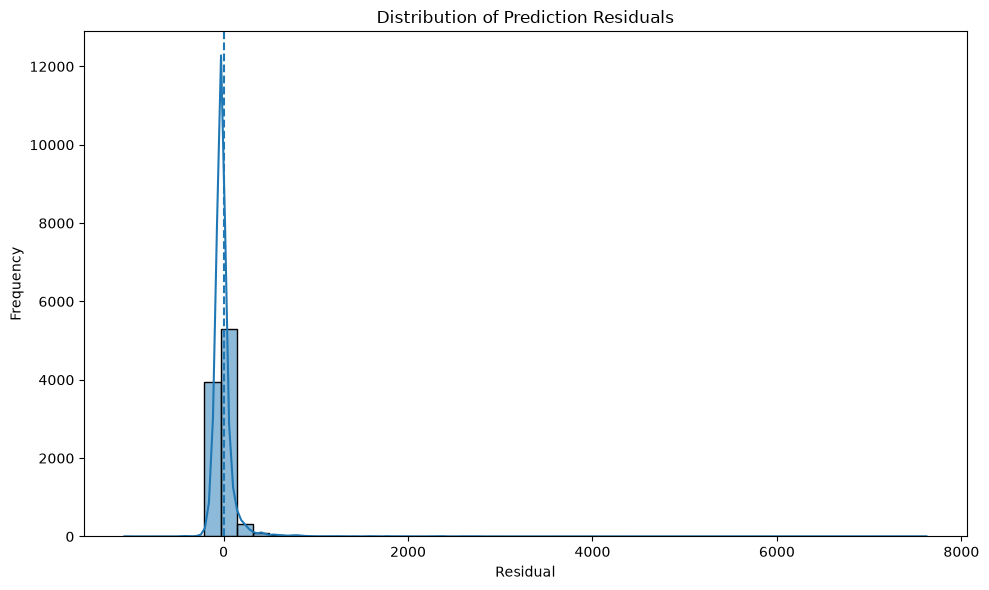

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Residuals")

plt.tight_layout()
plt.show()

## 34. Prediction Error Distribution

The distribution of absolute prediction errors is examined to understand how accurately the model predicts nightly Airbnb prices.

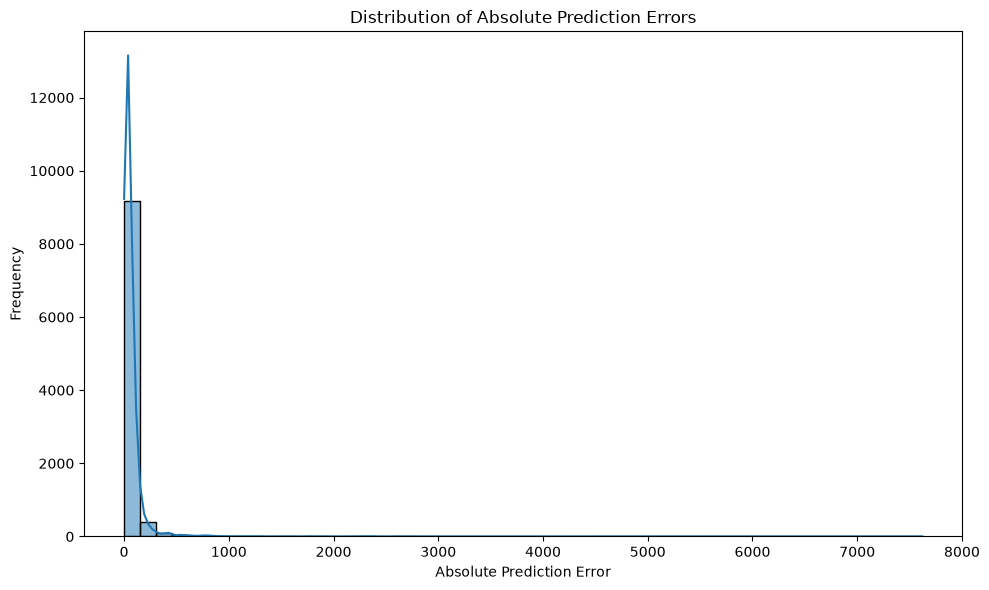

In [43]:
absolute_errors = np.abs(y_test - y_test_pred)

plt.figure(figsize=(10, 6))

sns.histplot(
    absolute_errors,
    bins=50,
    kde=True
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Prediction Errors")

plt.tight_layout()
plt.show()

## 35. Model Comparison

The initial models are compared with the final tuned Gradient Boosting model to determine whether hyperparameter optimization improved predictive performance.

In [44]:
final_comparison = results_df.copy()

tuned_result = pd.DataFrame({
    "Model": ["Tuned Gradient Boosting"],
    "MAE": [test_mae],
    "RMSE": [test_rmse],
    "R2": [test_r2]
})

final_comparison = pd.concat(
    [final_comparison, tuned_result],
    ignore_index=True
)

final_comparison.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Gradient Boosting,66.172267,181.976622,0.172856
1,Tuned Gradient Boosting,67.639816,184.272383,0.151854
2,Linear Regression,70.740417,186.096761,0.134977
3,Random Forest,66.944772,196.412535,0.036419


## 36. Model Performance Comparison

The models are compared using R² and RMSE to determine the effect of hyperparameter tuning.

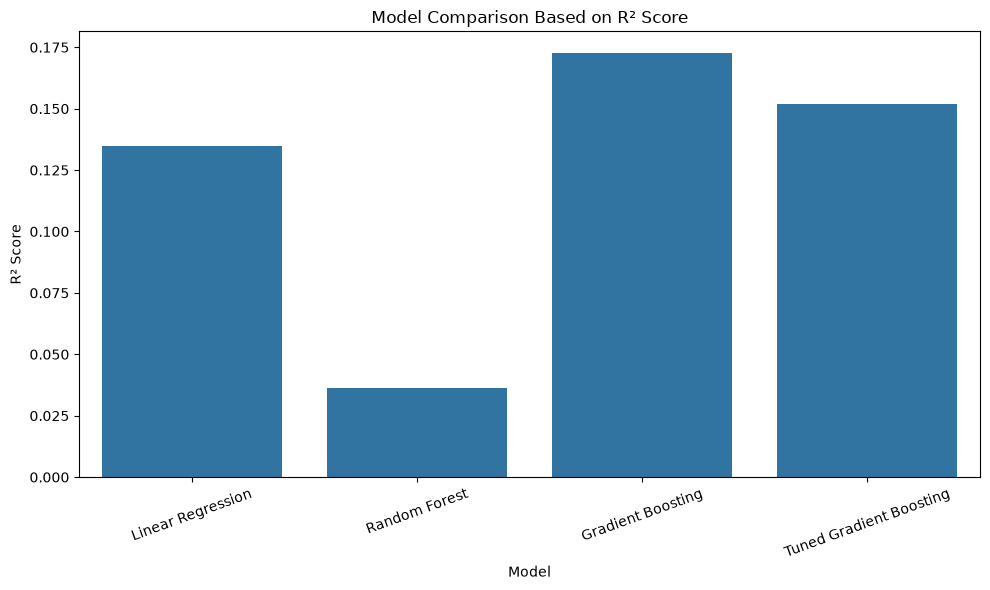

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="R2"
)

plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Model Comparison Based on R² Score")

plt.tight_layout()
plt.show()

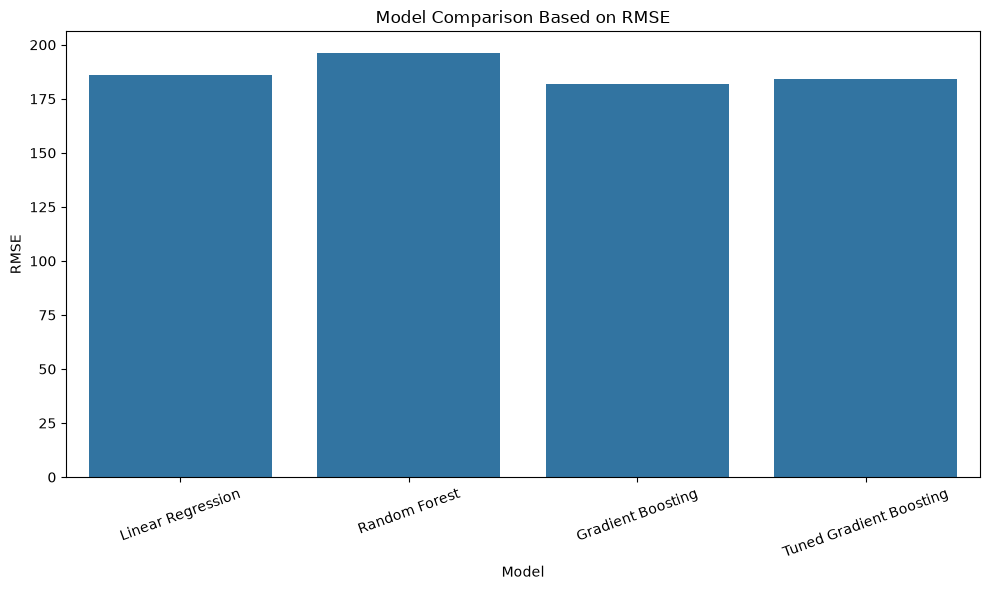

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="RMSE"
)

plt.xticks(rotation=20)
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison Based on RMSE")

plt.tight_layout()
plt.show()

## 37. Saving the Final Model

The complete preprocessing and prediction pipeline is saved using Joblib.

Since the preprocessing steps are included inside the pipeline, the saved object can directly accept raw user input and generate predictions.

In [47]:
joblib.dump(
    best_model,
    "airbnb_price_prediction_pipeline.pkl"
)

print("Final model pipeline saved successfully.")

Final model pipeline saved successfully.


In [48]:
loaded_model = joblib.load(
    "airbnb_price_prediction_pipeline.pkl"
)

sample_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print("Sample Predictions:")
print(sample_prediction)

Sample Predictions:
[116.23561688  98.62041747 156.50676561  73.24395474 125.92185846]


In [49]:
sample_listing = pd.DataFrame({
    "neighbourhood_group": ["Manhattan"],
    "neighbourhood": ["Upper West Side"],
    "latitude": [40.7870],
    "longitude": [-73.9754],
    "room_type": ["Entire home/apt"],
    "minimum_nights": [3],
    "number_of_reviews": [25],
    "reviews_per_month": [1.5],
    "calculated_host_listings_count": [2],
    "availability_365": [200]
})

predicted_price = loaded_model.predict(sample_listing)[0]

print(f"Estimated Nightly Price: ${predicted_price:.2f}")

Estimated Nightly Price: $245.65
